In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Ensemble
from sklearn.ensemble import VotingClassifier

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
lr = LogisticRegression(max_iter=500)
dt = DecisionTreeClassifier(max_depth=5)
svc = SVC(probability=True)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "SVM": svc
}

In [6]:
print("=== Base Models ===")
base_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    base_results[name] = acc
    print(f"{name}: {acc:.4f}")

=== Base Models ===
Logistic Regression: 0.9561
Decision Tree: 0.9474
SVM: 0.9474


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. Hard Voting

In [7]:

hard_vote = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svc', svc)
    ],
    voting='hard'
)

hard_vote.fit(X_train, y_train)
y_pred_hard = hard_vote.predict(X_test)

print("\nHard Voting Accuracy:", accuracy_score(y_test, y_pred_hard))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Hard Voting Accuracy: 0.9649122807017544


# 6. Soft Voting

In [8]:
soft_vote = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svc', svc)
    ],
    voting='soft'
)

soft_vote.fit(X_train, y_train)
y_pred_soft = soft_vote.predict(X_test)

print("Soft Voting Accuracy:", accuracy_score(y_test, y_pred_soft))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Soft Voting Accuracy: 0.9736842105263158


In [9]:
weighted_vote = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svc', svc)
    ],
    voting='soft',
    weights=[2, 1, 2]  # giving more importance to lr & svc
)

weighted_vote.fit(X_train, y_train)
y_pred_weighted = weighted_vote.predict(X_test)

print("Weighted Voting Accuracy:", accuracy_score(y_test, y_pred_weighted))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Weighted Voting Accuracy: 0.9649122807017544


In [10]:
results = {
    "Logistic Regression": base_results["Logistic Regression"],
    "Decision Tree": base_results["Decision Tree"],
    "SVM": base_results["SVM"],
    "Hard Voting": accuracy_score(y_test, y_pred_hard),
    "Soft Voting": accuracy_score(y_test, y_pred_soft),
    "Weighted Voting": accuracy_score(y_test, y_pred_weighted)
}

df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\nComparison:\n", df)


Comparison:
                  Model  Accuracy
0  Logistic Regression  0.956140
1        Decision Tree  0.947368
2                  SVM  0.947368
3          Hard Voting  0.964912
4          Soft Voting  0.973684
5      Weighted Voting  0.964912


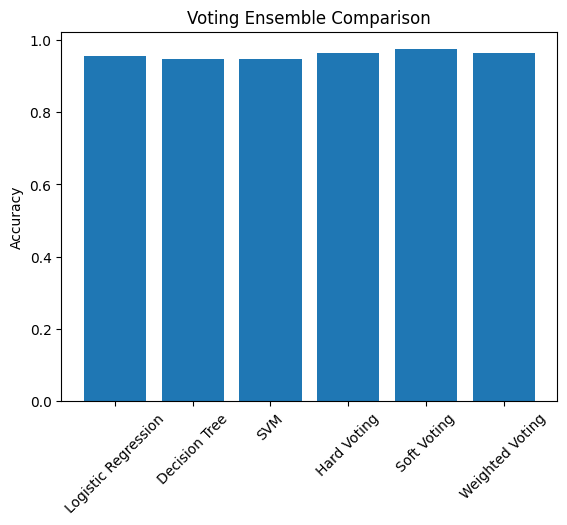

In [11]:
plt.bar(df["Model"], df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Voting Ensemble Comparison")
plt.ylabel("Accuracy")
plt.show()